In [5]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
dataset = pd.read_csv('../input/diabetes-data-set/diabetes.csv')

FileNotFoundError: [Errno 2] No such file or directory: '../input/diabetes-data-set/diabetes.csv'

In [7]:
import pandas as pd

dataset = pd.read_csv("diabetes.csv")

In [8]:
import os

print(os.getcwd())      # Current working directory
print(os.listdir())     # Files in current directory

C:\Users\parva\Desktop\nest\Diabetes prediction
['.ipynb_checkpoints', 'diabetes.csv', 'diabetes.ipynb']


In [9]:
import pandas as pd

dataset = pd.read_csv("diabetes.csv")

In [10]:
dataset = pd.read_csv("diabetes.csv")

print(dataset.head())
print(dataset.shape)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
(768, 9)


In [11]:
dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [12]:
dataset.shape

(768, 9)

In [13]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [14]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [15]:
dataset.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

<Axes: xlabel='Outcome', ylabel='count'>

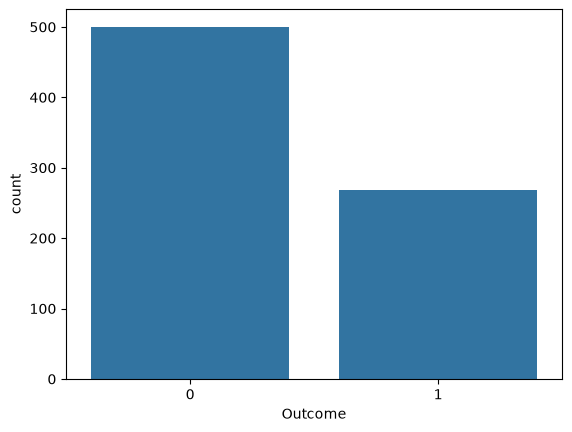

In [16]:
sns.countplot(x = 'Outcome',data = dataset)

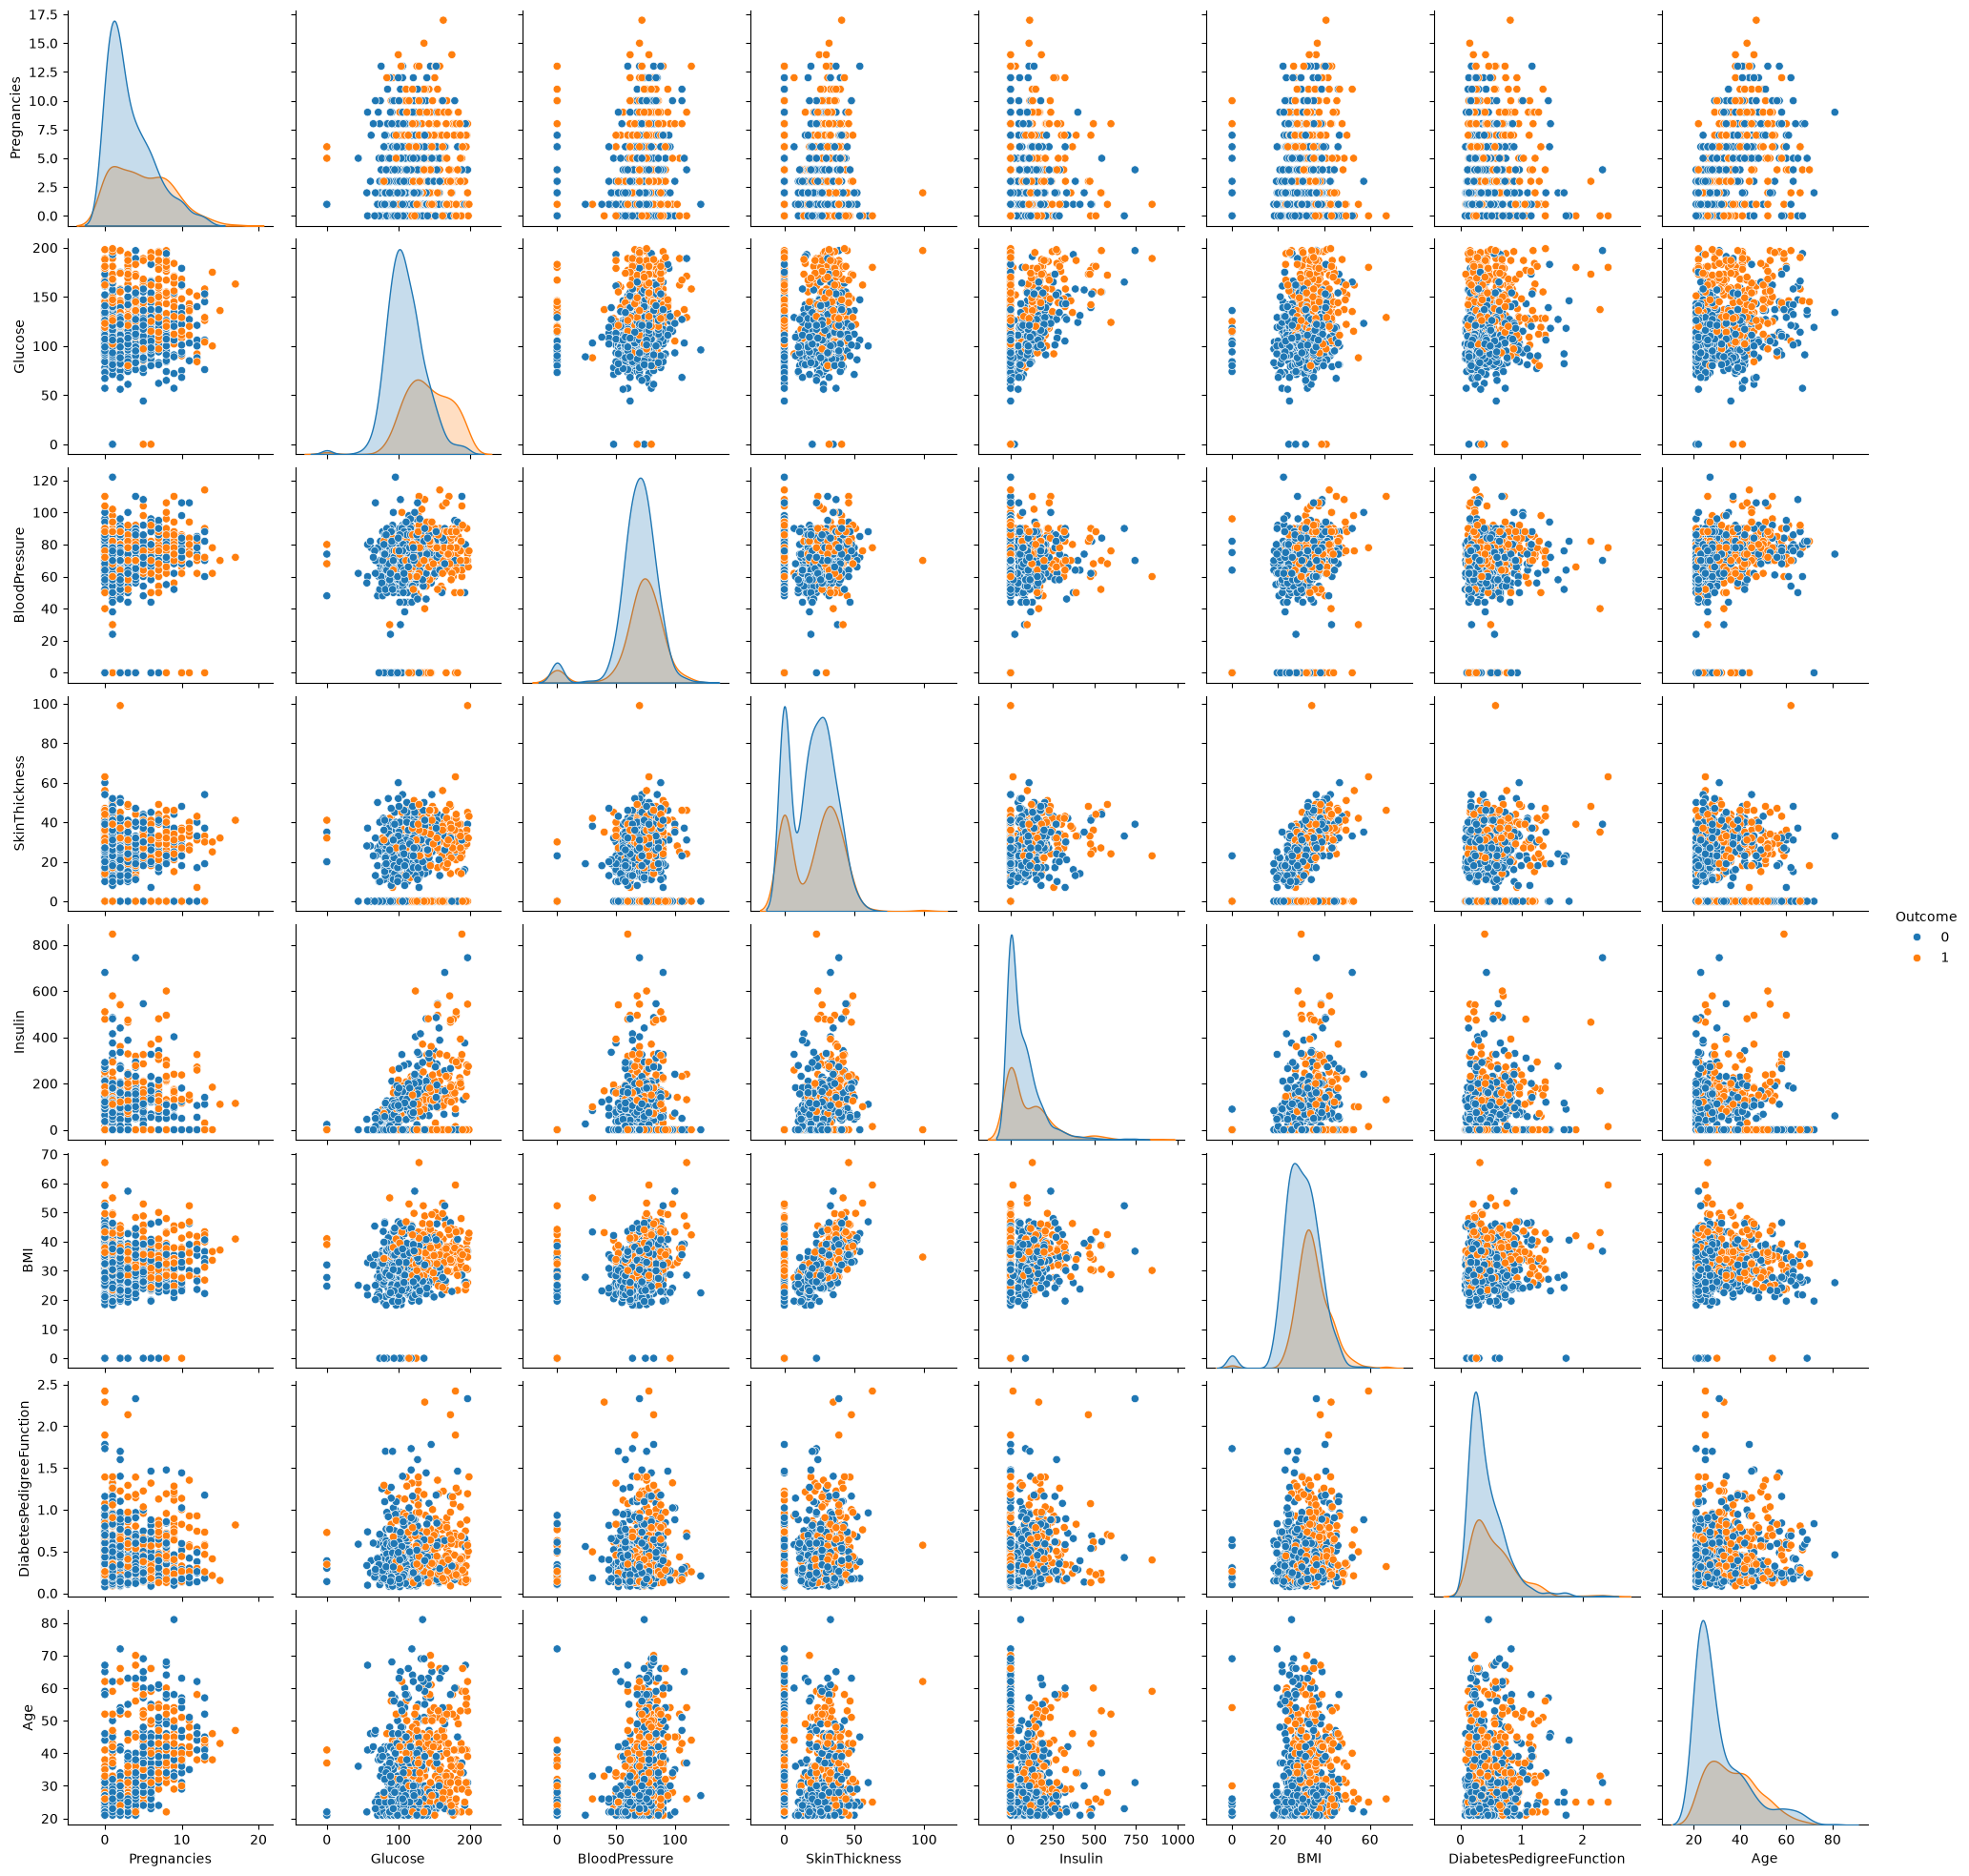

In [19]:
# Pairplot
sns.pairplot(data = dataset, hue = 'Outcome')
plt.show()

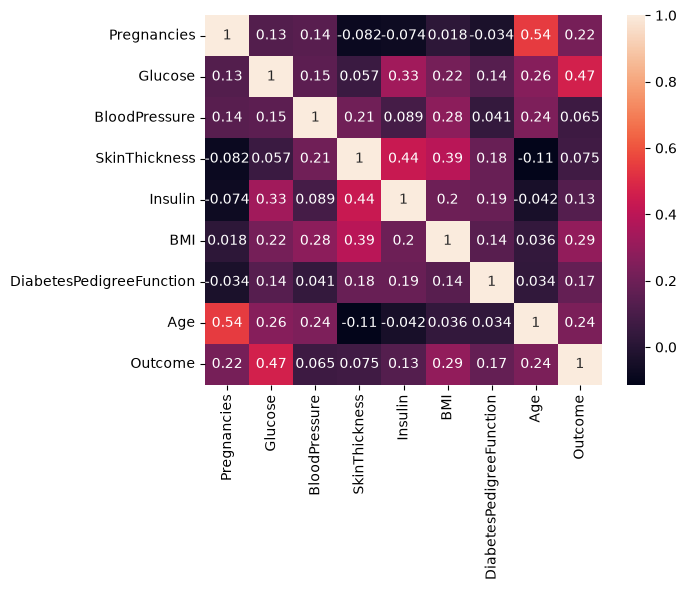

In [18]:
# Heatmap
sns.heatmap(dataset.corr(), annot = True)
plt.show()

In [21]:
# Replacing zero values with NaN
dataset_new = dataset
dataset_new[["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]] = dataset_new[["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]].replace(0, np.nan) 

In [22]:
dataset_new.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [25]:
dataset_new["Glucose"] = dataset_new["Glucose"].fillna(dataset_new["Glucose"].mean())
dataset_new["BloodPressure"] = dataset_new["BloodPressure"].fillna(dataset_new["BloodPressure"].mean())
dataset_new["SkinThickness"] = dataset_new["SkinThickness"].fillna(dataset_new["SkinThickness"].mean())
dataset_new["Insulin"] = dataset_new["Insulin"].fillna(dataset_new["Insulin"].mean())
dataset_new["BMI"] = dataset_new["BMI"].fillna(dataset_new["BMI"].mean())

In [26]:
dataset_new.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [27]:
y = dataset_new['Outcome']
X = dataset_new.drop('Outcome', axis=1)

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size = 0.20, random_state = 42, stratify = dataset_new['Outcome'] )

In [34]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, Y_train)
y_predict = model.predict(X_test)

C:\Users\parva\Desktop\nest\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [35]:
y_predict

array([1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0])

In [36]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, y_predict)
cm

array([[82, 18],
       [28, 26]])

<Axes: >

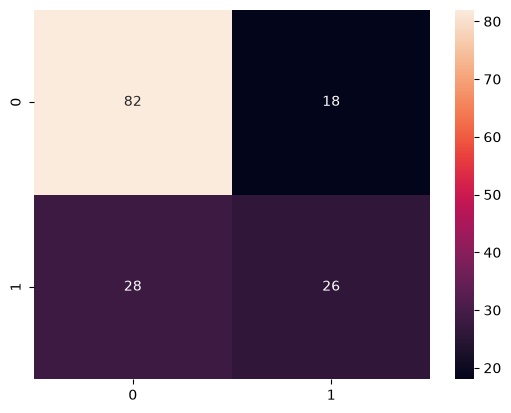

In [37]:
sns.heatmap(pd.DataFrame(cm), annot=True)

In [38]:
from sklearn.metrics import accuracy_score

In [39]:
accuracy =accuracy_score(Y_test, y_predict)
accuracy

0.7012987012987013

In [41]:
import pandas as pd

sample = pd.DataFrame(
    [[1,148,72,35,79.799,33.6,0.627,50]],
    columns=X.columns
)

y_predict = model.predict(sample)

print(y_predict)

if y_predict[0] == 1:
    print("Diabetic")
else:
    print("Non Diabetic")

[1]
Diabetic


In [44]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(Y_test, model.predict(X_test))
print("Accuracy:", accuracy)


Accuracy: 0.7012987012987013


In [45]:
import pickle

with open("diabetes_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!
